In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import shap

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)

print(f"Shape: {raw.shape}")
print(f"\nColumns:\n{raw.columns.tolist()}")

Shape: (7214, 53)

Columns:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


In [ ]:
df = raw.copy()


df = df[df['days_b_screening_arrest'] <= 30]
df = df[df['days_b_screening_arrest'] >= -30]


cols = [
    'id', 'sex', 'age', 'race',
    'juv_fel_count', 'juv_misd_count', 'priors_count',
    'c_charge_degree', 'decile_score', 'score_text',
    'two_year_recid'
]

df = df[cols].copy()


df_bw = df[df['race'].isin(['African-American', 'Caucasian'])].copy()


df_bw['high_risk'] = (df_bw['decile_score'] >= 5).astype(int)

print(f"Full dataset: {len(df)} rows")
print(f"Black and White only: {len(df_bw)} rows")
print(f"\nRace distribution:\n{df_bw['race'].value_counts()}")
print(f"\nActual recidivism rate: {df_bw['two_year_recid'].mean():.3f}")

Full dataset: 6172 rows
Black and White only: 5278 rows

Race distribution:
race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

Actual recidivism rate: 0.470


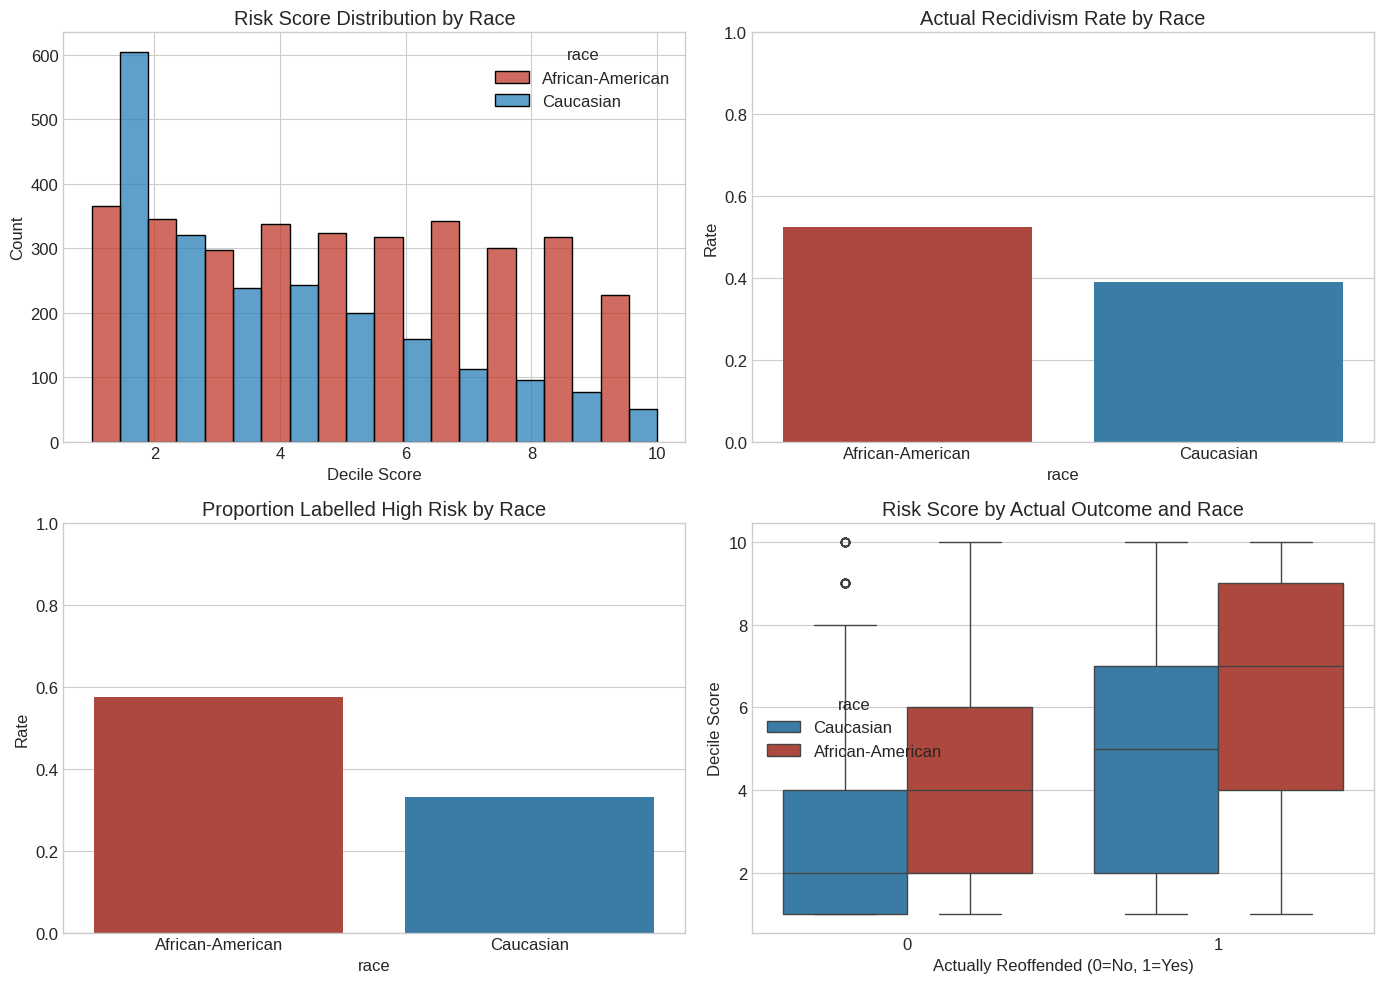

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution by race
sns.histplot(data=df_bw, x='decile_score', hue='race',
             multiple='dodge', bins=10, ax=axes[0,0],
             palette={'African-American': '#c0392b', 'Caucasian': '#2980b9'})
axes[0,0].set_title('Risk Score Distribution by Race')
axes[0,0].set_xlabel('Decile Score')

# 2. Actual recidivism rate by race
recid_by_race = df_bw.groupby('race')['two_year_recid'].mean().reset_index()
sns.barplot(data=recid_by_race, x='race', y='two_year_recid', ax=axes[0,1],
            palette={'African-American': '#c0392b', 'Caucasian': '#2980b9'})
axes[0,1].set_title('Actual Recidivism Rate by Race')
axes[0,1].set_ylabel('Rate')
axes[0,1].set_ylim(0, 1)

# 3. Proportion labelled high risk by race
highrisk = df_bw.groupby('race')['high_risk'].mean().reset_index()
sns.barplot(data=highrisk, x='race', y='high_risk', ax=axes[1,0],
            palette={'African-American': '#c0392b', 'Caucasian': '#2980b9'})
axes[1,0].set_title('Proportion Labelled High Risk by Race')
axes[1,0].set_ylabel('Rate')
axes[1,0].set_ylim(0, 1)

# 4. Score by actual outcome and race
sns.boxplot(data=df_bw, x='two_year_recid', y='decile_score',
            hue='race', ax=axes[1,1],
            palette={'African-American': '#c0392b', 'Caucasian': '#2980b9'})
axes[1,1].set_title('Risk Score by Actual Outcome and Race')
axes[1,1].set_xlabel('Actually Reoffended (0=No, 1=Yes)')
axes[1,1].set_ylabel('Decile Score')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def fairness_report(df, race_col, pred_col, outcome_col,
                    privileged='Caucasian', unprivileged='African-American'):

    results = {}

    for group in [privileged, unprivileged]:
        subset = df[df[race_col] == group]

        tp = len(subset[(subset[pred_col] == 1) & (subset[outcome_col] == 1)])
        tn = len(subset[(subset[pred_col] == 0) & (subset[outcome_col] == 0)])
        fp = len(subset[(subset[pred_col] == 1) & (subset[outcome_col] == 0)])
        fn = len(subset[(subset[pred_col] == 0) & (subset[outcome_col] == 1)])
        total = len(subset)

        results[group] = {
            'n': total,
            'positive_rate': (tp + fp) / total,
            'tpr': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0,
            'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
            'accuracy': (tp + tn) / total
        }

    p = results[privileged]
    u = results[unprivileged]


    print("FAIRNESS REPORT — COMPAS")

    print(f"\n{'Metric':<30} {'Caucasian':>12} {'Black':>12} {'Disparity':>12}")
    print("-" * 66)

    metrics = [
        ('N', 'n', False),
        ('Positive Rate (Demo. Parity)', 'positive_rate', True),
        ('True Positive Rate', 'tpr', True),
        ('False Positive Rate', 'fpr', True),
        ('False Negative Rate', 'fnr', True),
        ('Precision (PPV)', 'ppv', True),
        ('Accuracy', 'accuracy', True),
    ]

    for label, key, show_disparity in metrics:
        pv = p[key]
        uv = u[key]
        if show_disparity:
            disp = f"{uv/pv:.3f}" if pv > 0 else "N/A"
            print(f"{label:<30} {pv:>12.3f} {uv:>12.3f} {disp:>12}")
        else:
            print(f"{label:<30} {pv:>12.0f} {uv:>12.0f} {'—':>12}")

    print("\nDisparity = Black rate / Caucasian rate. 1.0 = equal.")
    print("Values > 1.0 mean Black defendants are flagged at higher rates.")

    return results

results = fairness_report(df_bw, 'race', 'high_risk', 'two_year_recid')

FAIRNESS REPORT — COMPAS

Metric                            Caucasian        Black    Disparity
------------------------------------------------------------------
N                                      2103         3175            —
Positive Rate (Demo. Parity)          0.331        0.576        1.741
True Positive Rate                    0.504        0.715        1.420
False Positive Rate                   0.220        0.423        1.923
False Negative Rate                   0.496        0.285        0.574
Precision (PPV)                       0.595        0.650        1.092
Accuracy                              0.672        0.649        0.966

Disparity = Black rate / Caucasian rate. 1.0 = equal.
Values > 1.0 mean Black defendants are flagged at higher rates.


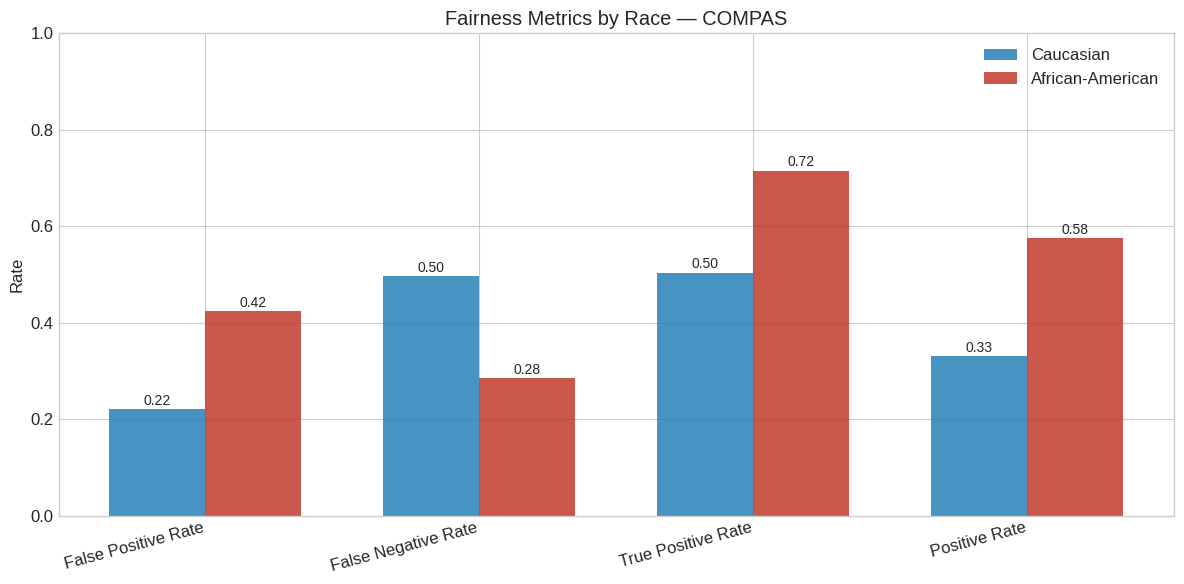

In [ ]:
metrics_plot = {
    'False Positive Rate': (results['Caucasian']['fpr'], results['African-American']['fpr']),
    'False Negative Rate': (results['Caucasian']['fnr'], results['African-American']['fnr']),
    'True Positive Rate': (results['Caucasian']['tpr'], results['African-American']['tpr']),
    'Positive Rate': (results['Caucasian']['positive_rate'], results['African-American']['positive_rate']),
}

labels = list(metrics_plot.keys())
caucasian_vals = [v[0] for v in metrics_plot.values()]
black_vals = [v[1] for v in metrics_plot.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, caucasian_vals, width, label='Caucasian', color='#2980b9', alpha=0.85)
bars2 = ax.bar(x + width/2, black_vals, width, label='African-American', color='#c0392b', alpha=0.85)

ax.set_ylabel('Rate')
ax.set_title('Fairness Metrics by Race — COMPAS')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fairness_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

print("THE CHOULDECHOVA IMPOSSIBILITY THEOREM")
print(""" \n
If a risk score is:
  (a) Calibrated — same score means same probability across groups
  (b) Has equal False Positive Rates across groups
  (c) Has equal False Negative Rates across groups

...then the base rates (actual recidivism rates) must be equal
across groups. If base rates differ, you CANNOT satisfy all three
simultaneously. You have to choose which error to minimise.
This is not a fixable bug. It is a mathematical constraint.
""")

# Show base rates
base_rates = df_bw.groupby('race')['two_year_recid'].mean()
print(f"Actual recidivism rates:")
for race, rate in base_rates.items():
    print(f"  {race}: {rate:.3f}")

print(f"\nBase rates differ by: {abs(base_rates.iloc[0] - base_rates.iloc[1]):.3f}")
print("\nThis gap means COMPAS cannot simultaneously satisfy")
print("calibration AND equal error rates. It has to fail somewhere.")
print("\nWhere it fails: False Positive Rate for Black defendants is")
print(f"  {results['African-American']['fpr']:.3f} vs {results['Caucasian']['fpr']:.3f} for white defendants.")
print(f"\nBlack defendants are {results['African-American']['fpr']/results['Caucasian']['fpr']:.1f}x more likely to be")
print("incorrectly labelled high risk when they will not reoffend.")

THE CHOULDECHOVA IMPOSSIBILITY THEOREM
 

If a risk score is:
  (a) Calibrated — same score means same probability across groups
  (b) Has equal False Positive Rates across groups
  (c) Has equal False Negative Rates across groups

...then the base rates (actual recidivism rates) must be equal
across groups. If base rates differ, you CANNOT satisfy all three
simultaneously. You have to choose which error to minimise.
This is not a fixable bug. It is a mathematical constraint.

Actual recidivism rates:
  African-American: 0.523
  Caucasian: 0.391

Base rates differ by: 0.132

This gap means COMPAS cannot simultaneously satisfy
calibration AND equal error rates. It has to fail somewhere.

Where it fails: False Positive Rate for Black defendants is
  0.423 vs 0.220 for white defendants.

Black defendants are 1.9x more likely to be
incorrectly labelled high risk when they will not reoffend.


In [ ]:
# Features
features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count']
target = 'two_year_recid'

df_bw['charge_binary'] = (df_bw['c_charge_degree'] == 'F').astype(int)
features.append('charge_binary')

X = df_bw[features].fillna(0)
y = df_bw[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sc, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test_sc)))

print("\nRandom Forest:")
print(classification_report(y_test, rf.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69       559
           1       0.65      0.57      0.61       497

    accuracy                           0.65      1056
   macro avg       0.65      0.65      0.65      1056
weighted avg       0.65      0.65      0.65      1056


Random Forest:
              precision    recall  f1-score   support

           0       0.65      0.69      0.67       559
           1       0.63      0.58      0.60       497

    accuracy                           0.64      1056
   macro avg       0.64      0.64      0.64      1056
weighted avg       0.64      0.64      0.64      1056



In [ ]:
df_test = X_test.copy()
df_test['true_label'] = y_test.values
df_test['lr_pred'] = lr.predict(X_test_sc)
df_test['rf_pred'] = rf.predict(X_test)
df_test['race'] = df_bw.loc[X_test.index, 'race'].values

print("LOGISTIC REGRESSION AUDIT")
print("-" * 40)
lr_results = fairness_report(df_test, 'race', 'lr_pred', 'true_label')

print("\n\nRANDOM FOREST AUDIT")
print("-" * 40)
rf_results = fairness_report(df_test, 'race', 'rf_pred', 'true_label')

LOGISTIC REGRESSION AUDIT
----------------------------------------
FAIRNESS REPORT — COMPAS

Metric                            Caucasian        Black    Disparity
------------------------------------------------------------------
N                                       429          627            —
Positive Rate (Demo. Parity)          0.277        0.501        1.805
True Positive Rate                    0.424        0.642        1.516
False Positive Rate                   0.181        0.347        1.910
False Negative Rate                   0.576        0.358        0.621
Precision (PPV)                       0.605        0.669        1.105
Accuracy                              0.662        0.648        0.978

Disparity = Black rate / Caucasian rate. 1.0 = equal.
Values > 1.0 mean Black defendants are flagged at higher rates.


RANDOM FOREST AUDIT
----------------------------------------
FAIRNESS REPORT — COMPAS

Metric                            Caucasian        Black    Disparity
--

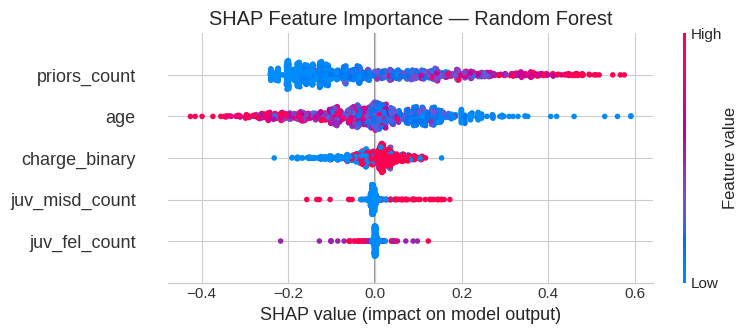

In [ ]:

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)


plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test,
                  feature_names=features,
                  show=False)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

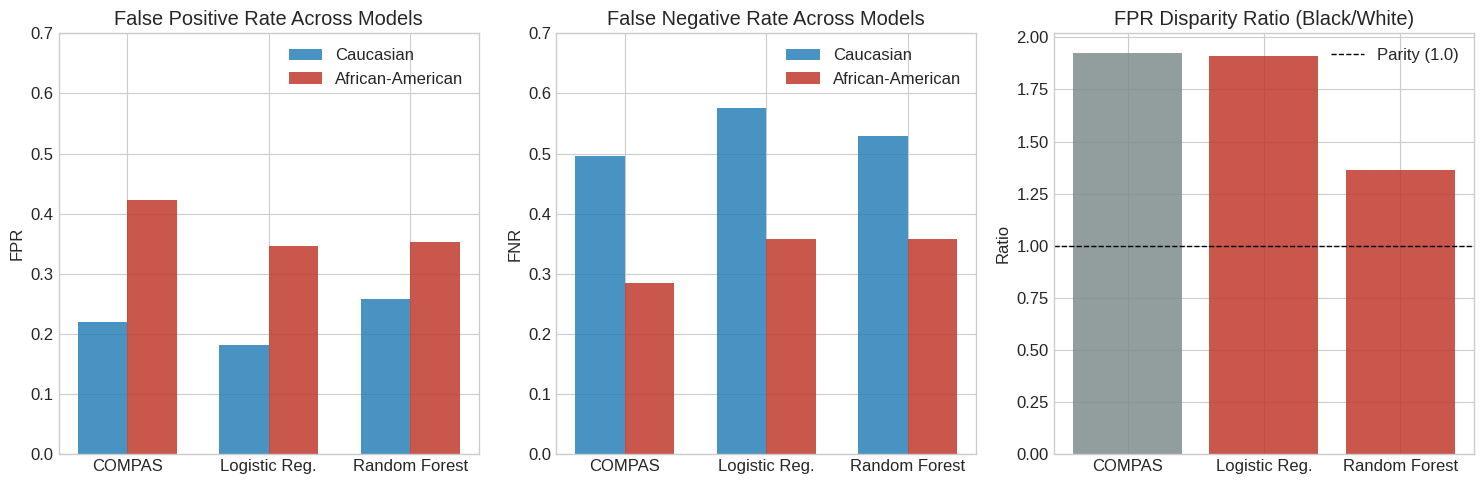

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


models = ['COMPAS', 'Logistic Reg.', 'Random Forest']
white_fpr = [
    results['Caucasian']['fpr'],
    lr_results['Caucasian']['fpr'],
    rf_results['Caucasian']['fpr']
]
black_fpr = [
    results['African-American']['fpr'],
    lr_results['African-American']['fpr'],
    rf_results['African-American']['fpr']
]

x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, white_fpr, width, label='Caucasian', color='#2980b9', alpha=0.85)
axes[0].bar(x + width/2, black_fpr, width, label='African-American', color='#c0392b', alpha=0.85)
axes[0].set_title('False Positive Rate Across Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylabel('FPR')
axes[0].set_ylim(0, 0.7)

white_fnr = [
    results['Caucasian']['fnr'],
    lr_results['Caucasian']['fnr'],
    rf_results['Caucasian']['fnr']
]
black_fnr = [
    results['African-American']['fnr'],
    lr_results['African-American']['fnr'],
    rf_results['African-American']['fnr']
]

axes[1].bar(x - width/2, white_fnr, width, label='Caucasian', color='#2980b9', alpha=0.85)
axes[1].bar(x + width/2, black_fnr, width, label='African-American', color='#c0392b', alpha=0.85)
axes[1].set_title('False Negative Rate Across Models')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].set_ylabel('FNR')
axes[1].set_ylim(0, 0.7)


fpr_disparity = [b/w if w > 0 else 0 for b, w in zip(black_fpr, white_fpr)]
axes[2].bar(models, fpr_disparity, color=['#7f8c8d', '#c0392b', '#c0392b'], alpha=0.85)
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Parity (1.0)')
axes[2].set_title('FPR Disparity Ratio (Black/White)')
axes[2].set_ylabel('Ratio')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()